## Data Analytics

### Chapter 21: Isolation Forest

**Isolation Forest** is an **unsupervised machine learning algorithm** for detecting outliers, especially in high-dimensional datasets. Its fundamental idea is ***Outliers are easier to isolate than normal data points.***

Isolation Forest builds many Isolation Trees, each created using completely random splits.

For every tree:

- Randomly select one feature.
- Randomly choose a split value within that feature's range.
- Divide the data into two groups.
- Repeat the process until each data point becomes isolated.

Unlike traditional decision trees, Isolation Trees do **not** search for the best split. Every split is chosen randomly, making the algorithm both simple and computationally efficient.

After constructing many Isolation Trees, the algorithm measures **how many splits (path length)** are required to isolate each data point.

- Data points isolated after only a few splits have a **short path length** and are likely to be outliers.
- Data points requiring many splits have a **long path length** and are considered normal observations.

The average path length across all trees is then converted into an anomaly score.

- **Short average path → Outlier**
- **Long average path → Normal data**

#### Import Required Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.tree import plot_tree

#### Generate a Dataset

In [7]:
np.random.seed(42)

# Normal samples
X_normal, _ = make_blobs(
    n_samples=800,
    centers=1,
    cluster_std=2,
    random_state=42
)

# Artificial outliers
X_outlier = np.random.uniform(
    low=-10,
    high=10,
    size=(200, 2)
)

X = np.vstack((X_normal, X_outlier))

df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

df.head(20)

,Feature1,Feature2
0,-2.351927,5.017885
1,-3.760323,9.805893
2,-1.823747,9.927793
3,-0.927134,7.195511
4,-2.345539,8.816507
5,-2.460177,10.010283
6,-4.458561,10.588455
7,-5.560248,7.630470
8,-1.636078,10.822156
9,-3.693985,7.286305


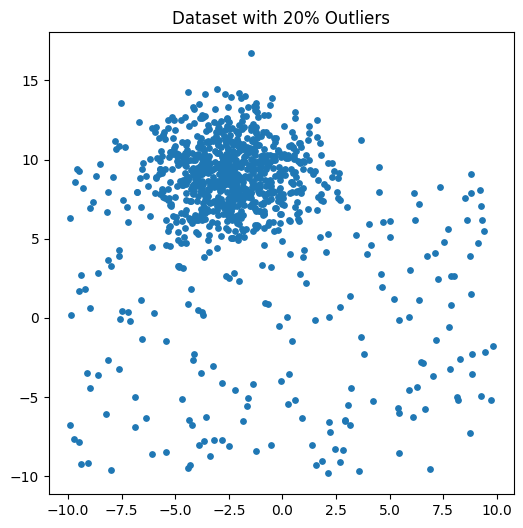

In [8]:
# Visualize the Dataset
plt.figure(figsize=(6,6))
plt.scatter(df["Feature1"], df["Feature2"], s=15)

plt.title("Dataset with 20% Outliers")
plt.show()

In [9]:
# Train the Isolation Forest
model = IsolationForest(
    n_estimators=100,
    contamination=0.20,
    random_state=42
)

model.fit(df)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.2
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [10]:
# Detect Outliers
df["Prediction"] = model.predict(df)

# -1 = Outlier
#  1 = Normal
df[df['Prediction'] == -1].head(20)

,Feature1,Feature2,Prediction
28,-7.902971,8.905696,-1
99,-4.179892,13.304584,-1
115,-3.612914,14.130685,-1
119,-7.235062,6.994825,-1
134,-7.357678,10.782377,-1
299,0.575022,13.026472,-1
336,-7.748688,10.658091,-1
348,-2.685762,14.173705,-1
373,-2.388737,13.940770,-1
402,-3.885498,13.519158,-1


In [11]:
# Count the detected samples.
df["Prediction"].value_counts()

Prediction
 1    800
-1    200
Name: count, dtype: int64

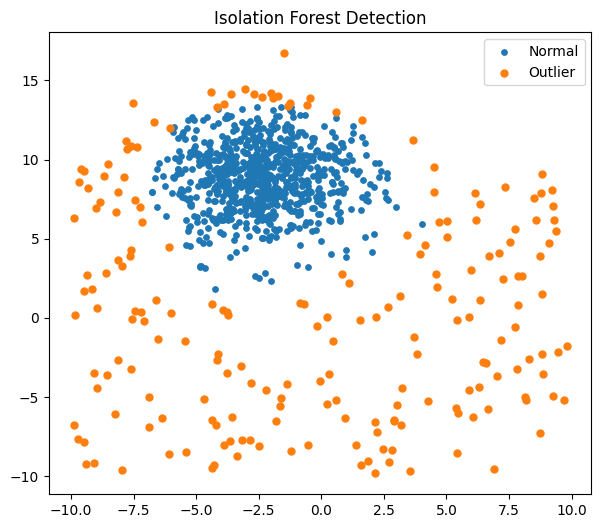

In [12]:
# Visualize the Results
plt.figure(figsize=(7,6))

normal = df[df["Prediction"] == 1]
outlier = df[df["Prediction"] == -1]

plt.scatter(
    normal["Feature1"],
    normal["Feature2"],
    s=15,
    label="Normal"
)

plt.scatter(
    outlier["Feature1"],
    outlier["Feature2"],
    s=25,
    label="Outlier"
)

plt.legend()
plt.title("Isolation Forest Detection")
plt.show()

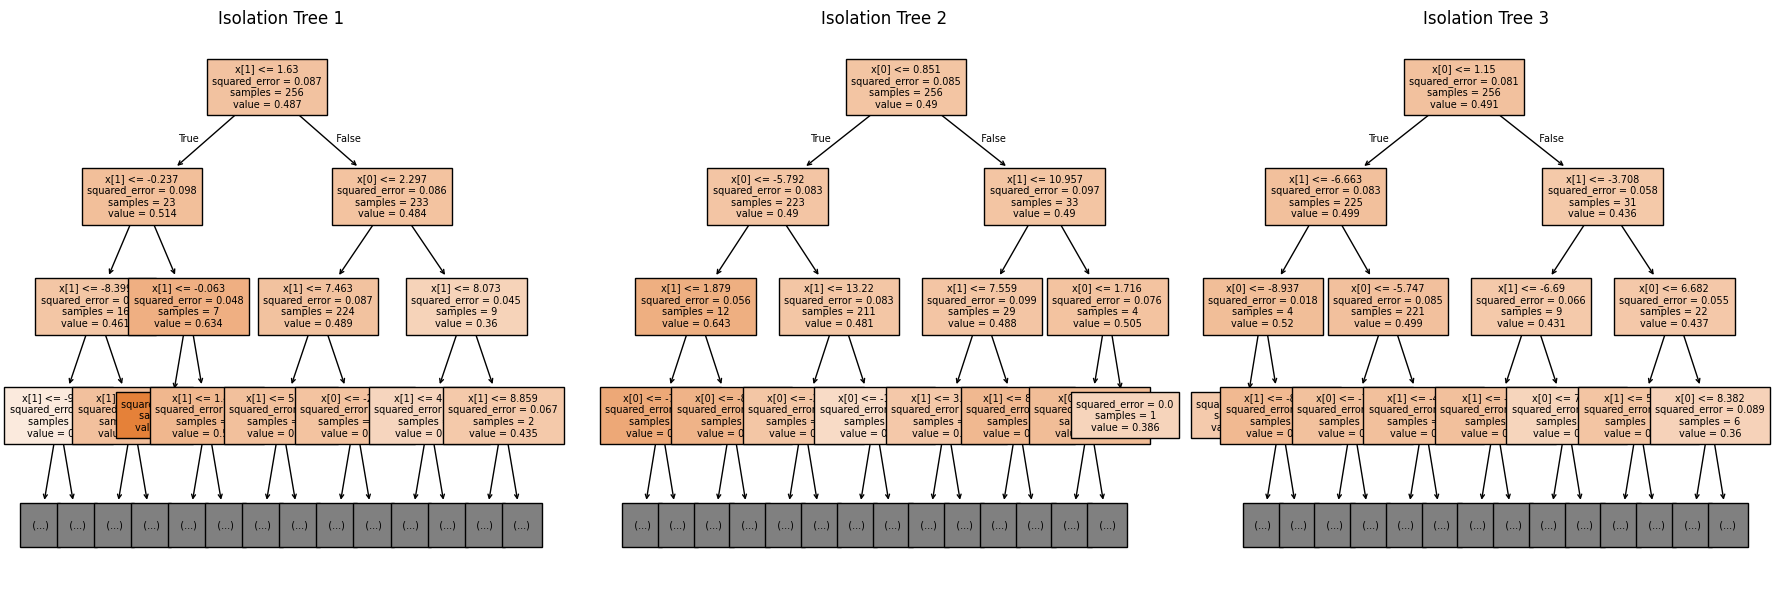

In [13]:
# Visualize Several Isolation Trees
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for i, ax in enumerate(axes):
    plot_tree(
        model.estimators_[i],
        max_depth=3,
        filled=True,
        fontsize=7,
        ax=ax
    )

    ax.set_title(f"Isolation Tree {i+1}")

plt.tight_layout()
plt.show()